In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict
import scienceplots

from scipy.stats import ttest_rel
from scipy import stats

In [2]:
DARK_BLUE  = (0.0, 0.4667, 0.7333)
LIGHT_BLUE = (0.2, 0.7333, 0.9333)
GREEN      = (0.0, 0.6, 0.5333)
ORANGE     = (0.9333, 0.4667, 0.2)
RED        = (0.8, 0.2, 0.0667)
PINK       = (0.9333, 0.2, 0.4667)
GRAY       = (0.7333, 0.7333, 0.7333)

SAVE = False

In [3]:
def boxplot_formatted(ax, data, colors, labels, **boxplot_kwargs):
    bp = ax.boxplot(
        data, 
        widths=0.3,
        patch_artist=True,
        **boxplot_kwargs
    )
    for box, color in zip(bp['boxes'], colors):
        box.set_facecolor(color)
        box.set_alpha(0.3)
        
    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.5)

    for whisker in bp['whiskers']:
        whisker.set_color('black')

    for cap in bp['caps']:
        cap.set_color('black')
        
    ax.set_xticks(np.arange(len(colors))+1)
    ax.set_xticklabels(labels)

In [4]:
# load dropout data
RUNS = {
    'Baseline': "/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/2_Dropout/02_24_21_46_LR_1_PW_04_Dropout_HigherDeltaBCM_DropoutBaseline",
    'Random': '/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/2_Dropout/02_24_23_19_LR_1_PW_04_Dropout_HigherDeltaBCM_OtherDropout',
    'LargeY': "/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/2_Dropout/02_24_22_42_LR_1_PW_04_Dropout_HigherDeltaBCM_Dropout0167",
    'SmallY': "/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/2_Dropout/02_24_22_13_LR_1_PW_04_Dropout_HigherDeltaBCM_Dropout2345",
    'All': "/Users/juliuswuerzler/Desktop/Results_Thesis/Delta_BCM_Update/2_Dropout/02_25_12_40_LR_1_PW_04_Dropout_HigherDeltaBCM_All"
}

data_dropout = []

dropout_07_mask = np.array([ 1,  3,  8,  9, 12, 16, 19, 20])

for run in RUNS:
    with open(RUNS[run] + "/summary.json", "r") as f:
        d = json.load(f)
    data_dropout.append(np.array(d["results"]))
data_dropout = np.array(data_dropout).T

<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_88235/2542510324.py:31: SyntaxWarning: invalid escape sequence '\D'
  ["Random", "Large $\Delta$y\nInputs→Motor",  "Small $\Delta$y\nInputs→Motor", "All Inputs→Motor"])
/var/folders/5j/y5kkrfqd203frqztz88nnmqr0000gn/T/ipykernel_88235/2542510324.py:31: SyntaxWarning: invalid escape sequence '\D'
  ["Random", "Large $\Delta$y\nInputs→Motor",  "Small $\Delta$y\nInputs→Motor", "All Inputs→Motor"])


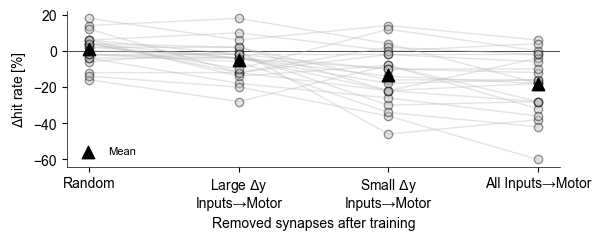

In [ ]:
plt.style.use(['nature_d'])

fig, axs = plt.subplot_mosaic([["Dropout"]],width_ratios=[1])

axs["Dropout"].axhline(0, color='black', linewidth=0.5)
axs["Dropout"].plot(np.arange(data_dropout.shape[1]-1) + 1, (data_dropout[:,1:] - data_dropout[:, [0]]).T * 100,
                    '-o', color=GRAY, alpha=0.4,
                    markeredgecolor='black',
                    markersize=6)

# Percent change relative to column 0
delta = (data_dropout[:, 1:] - data_dropout[:, [0]]) * 100
mean_delta = delta.mean(axis=0)
x = np.arange(data_dropout.shape[1] - 1) + 1

# Plot mean line
axs["Dropout"].scatter(
    x,
    mean_delta,
    color='black',        # distinct color
    marker="^",
    # linewidth=2.5,        # thicker
    s=80,
    label='Mean',
    zorder=10
)

axs["Dropout"].set_xlabel("Removed synapses after training")
axs["Dropout"].set_ylabel(r"$\Delta$hit rate [%]")
axs["Dropout"].set_xticks([1,2,3,4],
                          ["Random", "Large $\Delta$y\nInputs→Motor",  "Small $\Delta$y\nInputs→Motor", "All Inputs→Motor"])

w, h = fig.get_size_inches()
fig.set_size_inches(w, 3.5)

axs["Dropout"].legend()

fig.tight_layout()
if SAVE:
    fig.savefig("output/fig_3AB_Dropout.pdf", dpi=300)

plt.show()

In [6]:
def get_paired_ttest_statistics(data, group, bonferroni_factor, alpha=0.05):
    s = data[0]
    e = data[1]
    
    group1 = group[0]
    group2 = group[1]
    
    if s.shape != e.shape:
        raise ValueError(f"Shape mismatch: s_acc {s.shape} vs e_acc {e.shape}")

    d = e - s
    n = d.size
    df = n - 1

    mean_s = s.mean()
    mean_e = e.mean()
    mean_diff = d.mean()
    sd_diff = d.std(ddof=1)
    se_diff = sd_diff / np.sqrt(n)

    # Paired t-test (two-sided)
    t_stat_2s, p_val_2s = ttest_rel(e, s)

    # Bonferroni adjustment
    m = int(bonferroni_factor)
    if m <= 0:
        raise ValueError("bonferroni_factor must be a positive integer")

    alpha_adj = alpha / m
    p_val_bonf = min(p_val_2s * m, 1.0)

    # CI using adjusted alpha (Bonferroni-corrected familywise)
    t_crit_bonf = stats.t.ppf(1 - alpha_adj / 2, df=df)
    ci_low_bonf = mean_diff - t_crit_bonf * se_diff
    ci_high_bonf = mean_diff + t_crit_bonf * se_diff

    # (Optional) uncorrected 95% CI for reference
    t_crit = stats.t.ppf(1 - alpha / 2, df=df)
    ci_low = mean_diff - t_crit * se_diff
    ci_high = mean_diff + t_crit * se_diff

    # Effect size: Cohen's dz
    cohens_dz = mean_diff / sd_diff if sd_diff > 0 else np.inf

    # Reporting
    sig_unc = p_val_2s < alpha
    sig_bonf = p_val_2s < alpha_adj   # equivalent and cleaner

    print(f"Paired comparison per seed: {group2} - {group1}")
    print(f"n = {n}")
    print(f"{group1}: mean = {mean_s:.6f}")
    print(f"{group2}: mean = {mean_e:.6f}")
    print(f"mean difference ({group2} - {group1}) = {mean_diff:.6f}")
    print(f"sd(diff) = {sd_diff:.6f}, se(diff) = {se_diff:.6f}")
    print(f"t({df}) = {t_stat_2s:.6f}")
    print(f"p (two-sided, uncorrected) = {p_val_2s:.6g} {'*' if sig_unc else ''}")

    print(f"\nUncorrected 95% CI for mean difference = "
          f"[{ci_low:.6f}, {ci_high:.6f}]")

    print(f"\nBonferroni correction:")
    print(f"m = {m}, alpha_adj = {alpha_adj:.6g}")
    print(f"p_bonf = {p_val_bonf:.6g} {'*' if sig_bonf else ''}")

    ci_level_bonf = 100 * (1 - alpha_adj)
    print(f"Bonferroni-adjusted {ci_level_bonf:.3f}% CI = "
          f"[{ci_low_bonf:.6f}, {ci_high_bonf:.6f}]")

    print(f"\nEffect size:")
    print(f"Cohen's dz = {cohens_dz:.6f}")
    print("--------------------------------------------------\n")

In [7]:
baseline = data_dropout.T[0]  # baseline scores for 22 seeds

for i, run in enumerate(RUNS):
    if run == "Baseline":
        continue
    get_paired_ttest_statistics([data_dropout.T[0], data_dropout.T[i]], ["Baseline", run], bonferroni_factor=20)

Paired comparison per seed: Random - Baseline
n = 22
Baseline: mean = 0.590909
Random: mean = 0.600000
mean difference (Random - Baseline) = 0.009091
sd(diff) = 0.084567, se(diff) = 0.018030
t(21) = 0.504219
p (two-sided, uncorrected) = 0.619357 

Uncorrected 95% CI for mean difference = [-0.028404, 0.046586]

Bonferroni correction:
m = 20, alpha_adj = 0.0025
p_bonf = 1 
Bonferroni-adjusted 99.750% CI = [-0.052795, 0.070977]

Effect size:
Cohen's dz = 0.107500
--------------------------------------------------

Paired comparison per seed: LargeY - Baseline
n = 22
Baseline: mean = 0.590909
LargeY: mean = 0.538182
mean difference (LargeY - Baseline) = -0.052727
sd(diff) = 0.102455, se(diff) = 0.021843
t(21) = -2.413874
p (two-sided, uncorrected) = 0.0249984 *

Uncorrected 95% CI for mean difference = [-0.098153, -0.007301]

Bonferroni correction:
m = 20, alpha_adj = 0.0025
p_bonf = 0.499969 
Bonferroni-adjusted 99.750% CI = [-0.127704, 0.022249]

Effect size:
Cohen's dz = -0.514640
-----

In [8]:
get_paired_ttest_statistics([data_dropout.T[3], data_dropout.T[4]], ["SmallY", "LargeY"], bonferroni_factor=20)

Paired comparison per seed: LargeY - SmallY
n = 22
SmallY: mean = 0.457273
LargeY: mean = 0.407273
mean difference (LargeY - SmallY) = -0.050000
sd(diff) = 0.106324, se(diff) = 0.022668
t(21) = -2.205721
p (two-sided, uncorrected) = 0.0386818 *

Uncorrected 95% CI for mean difference = [-0.097141, -0.002859]

Bonferroni correction:
m = 20, alpha_adj = 0.0025
p_bonf = 0.773636 
Bonferroni-adjusted 99.750% CI = [-0.127808, 0.027808]

Effect size:
Cohen's dz = -0.470261
--------------------------------------------------

